# Full Model Development

## Set Config

In [1]:
# ライブラリのインポート
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import h2o
from h2o.automl import H2OAutoML
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

In [2]:
print(np.__version__)

1.26.4


In [3]:
# フォルダ設定
data_dir = '../data/'
output_dir = '../output/'
result_dir = '../output/results'

# date, version
# dateはデータを出力した日付で、特徴量tableにファイル名に含まれる
# 同じ特徴量tableに対して複数回のモデル構築を行う場合は、versionを変更する
date = '20260202_emergency'
model_type = 'full'
within = '72h'
ver_no = 1

# データのファイル名
train_csv_without_lag = f'{date}_df_development_{within}_train_sampled_without_lag.csv'
test_csv_without_lag = f'{date}_df_development_{within}_test_sampled_without_lag.csv'

In [4]:
# 保存するフォルダやファイル名を指定
roc_figure_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_ROC_curve_without_lag.png'
prc_figure_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_PRC_curve_without_lag.png'
calibration_figure_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_Calibration_plot_without_lag.png'
feature_file_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_selected_features_without_lag.csv'
best_model_folder_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_h2omodel_best_without_lag'
model_path_file_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_model_path_without_lag.txt'
SHAP_figure_file_name_without_lag = date + '_' + model_type + '_' + within + '_model_ver' + str(ver_no) + '_SHAP__without_lag'

In [ ]:
# 使用する特徴量
vars_with_lag = [
        # static
        'time_window_index','female','icu_admit_time','age',
        # 'icu_admission_type', 
        # diagnosis_category
        'covid19', 'sepsis', 'stroke', 
        'poisoning', 
        'anaphylaxis', 
        'burn', 'temperature_disorder', 
        'hanging_asphyxiation', 
        'trauma',
        'infection', 'neoplasms', 'circulatory', 'respiratory', 'digestive', 'neurological',
        'genitourinary', 'electrolyte_metabolic_disorders', 'musculoskeletal', 'psychiatric',
        # apache2
        'apache2_score',
        # charlson
        'charlson_comorbidity_index','myocardial_infarct','congestive_heart_failure',
        'peripheral_arterial_disease','cerebrovascular_disease','dementia',
        'chronic_pulmonary_disease','connective_tissue_disease','peptic_ulcer_disease',
        'mild_liver_disease','diabetes_without_cc','diabetes_with_cc','paraplegia',
        'renal_disease','malignant_cancer','severe_liver_disease','metastatic_solid_tumor',
        'aids',
        # 'age_score',
        # current time of day
        'current_time_of_day',
        # vital
        'bt50', 
        'hr10','hr50','hr90','hr_sd',
        'delta_hr50_lag1','delta_hr50_lag6','delta_hr50_lag12',
        'rr10','rr50','rr90','rr_sd',
        'delta_rr50_lag1','delta_rr50_lag6','delta_rr50_lag12',
        'sbp10','sbp50','sbp90','sbp_sd',
        'delta_sbp50_lag1','delta_sbp50_lag6','delta_sbp50_lag12',
        'mbp10','mbp50','mbp90','mbp_sd',
        'delta_mbp50_lag1','delta_mbp50_lag6','delta_mbp50_lag12',
        'dbp10','dbp50','dbp90','dbp_sd',
        'delta_dbp50_lag1','delta_dbp50_lag6','delta_dbp50_lag12',
        'spo2_10','spo2_50','spo2_90','spo2_sd',
        'delta_spo2_50_lag1','delta_spo2_50_lag6','delta_spo2_50_lag12',
        'bp_invasive',
         # mechanical ventilation
        'fio2_ordered','peep_ordered', 'mv_duration', 'inspiratory_pressure',
        'delta_fio2_ordered_lag1','delta_fio2_ordered_lag6','delta_fio2_ordered_lag12',
        'delta_peep_ordered_lag1','delta_peep_ordered_lag6','delta_peep_ordered_lag12',
        # weight
        'body_weight', 
        # GCS
        'gcs_e','gcs_v','gcs_m', 
        # blood gas
        'ph','pao2','pvo2','paco2','pvco2','bg_lactate','bg_glucose', 
        # lab
        'wbc','hemoglobin','platelet','sodium','creatinine','potassium', 
        'aspartate_aminotransferase','blood_urea_nitrogen','alanine_aminotransferase',
        'total_bilirubin','crp','albumin',
        # rass
        'rass_score',
        # sofa
        'respiration_24hours','coagulation_24hours','liver_24hours',
        'cardiovascular_24hours','cns_24hours','renal_24hours','sofa_24hours',
        # in out
        'cumsum_in','cumsum_out','cumsum_balance',
        'window_total_output', 'window_urinary_output', 'input_amount',
        # drug
        'active_ingredient_propofol','active_ingredient_noradrenaline','active_ingredient_fentanyl',
        'active_ingredient_dexmedetomidine','active_ingredient_dopamine','active_ingredient_midazolam',
        'active_ingredient_dobutamine','active_ingredient_landiolol','active_ingredient_vasopressin',
        'active_ingredient_remifentanil','active_ingredient_thiamylal','active_ingredient_adrenaline',
        'active_ingredient_vecuronium',
        # 'active_ingredient_rocuronium',
        #transfusion
        'transfusion_rbc','transfusion_platelet','transfusion_plasma','transfusion_albumin',
        'y']

vars_without_lag = [v for v in vars_with_lag if not v.startswith('delta_')]

In [6]:
# H2Oの初期化
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,7 hours 29 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.5
H2O_cluster_version_age:,"1 year, 5 months and 25 days"
H2O_cluster_name:,H2O_from_python_unknownUser_zl3h0i
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,20.69 Gb
H2O_cluster_total_cores:,28
H2O_cluster_allowed_cores:,28
H2O_cluster_status:,"locked, healthy"


In [7]:
# h2oを使ってモデルを学習させる関数
def get_aml_model(path_train: str, path_test: str, vars: list, random_seed: int) -> None:
    # ファイルの読み込み
    train = h2o.import_file(os.path.join(data_dir, path_train))
    train = train[vars]
    test = h2o.import_file(os.path.join(data_dir, path_test))
    test = test[vars]

    # 特徴量と目的変数の指定
    x = train.columns
    y = 'y'
    x.remove(y)
    train[y] = train[y].asfactor()
    test[y] = test[y].asfactor()
    
    # モデルの学習
    aml = H2OAutoML(max_models=20, seed=random_seed)
    aml.train(x=x, y=y, training_frame=train)

    return aml, train, test

## Model Development (without lag model)

In [8]:
# もし特徴量を保存するフォルダがなければ作成
if not os.path.exists(output_dir + 'features/'):
    os.makedirs(output_dir + 'features/')

# 学習に使用した特徴量を書き出す
with open(output_dir + 'features/' + feature_file_name_without_lag, "w") as file:
    for feat in vars_without_lag:
        file.write(feat + "\n")

In [9]:
# モデルを学習させる
aml_delirium_full, train_full, test_full = get_aml_model(train_csv_without_lag, test_csv_without_lag, vars_without_lag, 710)

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [10]:
# それぞれのモデルの性能を確認
lb_delirium_full = aml_delirium_full.leaderboard
lb_delirium_full.head(rows=lb_delirium_full.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_4_20260223_142347,0.996166,0.0707661,0.994014,0.0272321,0.138508,0.0191845
StackedEnsemble_BestOfFamily_1_AutoML_4_20260223_142347,0.99609,0.0713661,0.993896,0.0274257,0.13914,0.0193598
XGBoost_grid_1_AutoML_4_20260223_142347_model_2,0.996044,0.0723223,0.993811,0.0277004,0.139918,0.019577
XGBoost_grid_1_AutoML_4_20260223_142347_model_3,0.992018,0.10583,0.987088,0.0413314,0.171209,0.0293125
GBM_1_AutoML_4_20260223_142347,0.991834,0.149192,0.98662,0.0430695,0.191735,0.0367625
XGBoost_2_AutoML_4_20260223_142347,0.99083,0.113829,0.984776,0.0439225,0.177324,0.0314436
XGBoost_grid_1_AutoML_4_20260223_142347_model_1,0.990817,0.114828,0.984833,0.0447281,0.178401,0.0318269
XGBoost_1_AutoML_4_20260223_142347,0.99029,0.117732,0.984071,0.0471478,0.181292,0.0328666
GBM_4_AutoML_4_20260223_142347,0.987885,0.180276,0.980604,0.0537051,0.214429,0.0459797
XGBoost_3_AutoML_4_20260223_142347,0.987374,0.147521,0.978128,0.0529086,0.199911,0.0399645


## Evaluate Best Model Performance

Stacked ensampleではSHAPスコアが出せないため、stacked ensemble以外のモデルを取得する。

In [11]:
# 学習結果を表示というセクションのテーブルから、Stacked Ensemble以外のモデルを選び、model_selectedにそのモデル名を入れる
# Stacked Ensemble以外のもののうち、一番性能が良かったものを選ぶ
lb_df = lb_delirium_full.as_data_frame()
filtered_lb = lb_df[~lb_df['model_id'].str.startswith('StackedEnsemble')]
# filtered_lb = filtered_lb[filtered_lb['model_id'].str.startswith('XGBoost')] # XGBoostのみに絞る
model_selected = filtered_lb.iloc[0]['model_id']
model_type = model_selected.split('_')[0]
best_model = h2o.get_model(model_selected)
print(f'Best model: {model_type}')

Best model: XGBoost


/workspaces/research-nms-delirium-2025-4/.venv/lib/python3.12/site-packages/h2o/frame.py:1981: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [12]:
# 最も性能が良かったモデルのパフォーマンスを取得
perf_full = best_model.model_performance(test_full)

# 最も性能が良かったモデルのAUCを確認
auroc_full = perf_full.auc()
print(f"Test AUROC: {auroc_full}")

Test AUROC: 0.7937091150293638


## Precision & Specificity

In [13]:
# 最も性能が良かったモデルを使って予測を行い、結果を保存
predict = best_model.predict(test_full)
test_full['predict'] = predict['p1']
test_df = test_full.as_data_frame()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


/workspaces/research-nms-delirium-2025-4/.venv/lib/python3.12/site-packages/h2o/frame.py:1981: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [14]:
# 実際のラベルと予測確率を取得
y_true = test_df['y']
y_prob = test_df['predict']

In [15]:

# Sensitivityを指定したときに、そのsensitivityを実現する閾値を求める関数
def find_threshold_for_sensitivity(y_true, y_prob, sensitivity):
    thresholds = np.arange(0.0, 1.0, 0.00001)
    correct_thresholds = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        if recall_score(y_true, y_pred) >= sensitivity:
            correct_thresholds.append(threshold)
        else:
            break
    if correct_thresholds:
        return np.max(correct_thresholds)
    else:
        return None

# 実現したいsensitivityを指定
desired_sensitivity = 0.8

# 指定したsensitivityを実現する閾値を求める
threshold = find_threshold_for_sensitivity(y_true, y_prob, desired_sensitivity)

# 閾値が見つかった場合、その閾値でのprecisionとspecificityを求める
if threshold is not None:
    print(f'Threshold for sensitivity {desired_sensitivity}: {np.round(threshold, 10)}')
    
    # 閾値を使って予測を行う
    y_pred = (y_prob >= threshold).astype(int)
    
    # 実際のラベルと予測されたラベルを用いてprecisionを求める
    precision = precision_score(y_true, y_pred)
    
    # 実際のラベルと予測されたラベルを用いてconfusion matrixを求める
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # True negative, false positiveの値を元にspecificityを求める
    specificity = tn / (tn + fp)
    
    print(f'Precision: {precision}')
    print(f'Specificity: {specificity}')
else:
    print(f'No threshold found to achieve sensitivity of {desired_sensitivity}')

Threshold for sensitivity 0.8: 0.01365
Precision: 0.5515497366211162
Specificity: 0.6316969183986959


## ROC Curve

Test AUROC: 0.7927782054878476


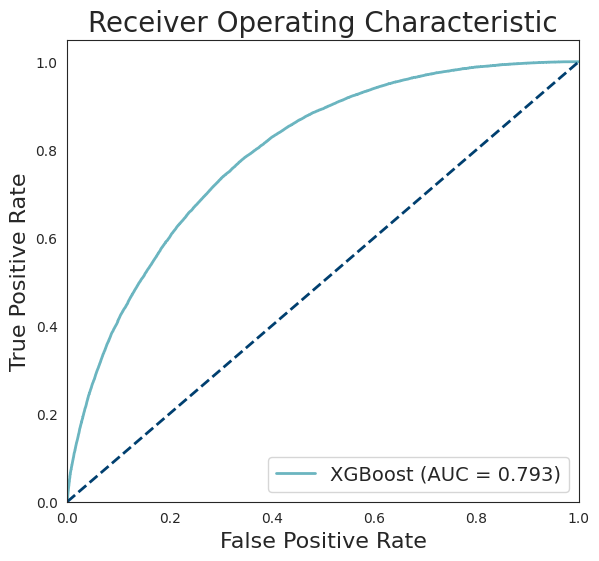

In [16]:
# ROC curveとAUCを求める
fpr1, tpr1, _ = roc_curve(test_df['y'], test_df['predict'])
roc_auc1 = auc(fpr1, tpr1)
print(f'Test AUROC: {roc_auc1}')

# 結果をプロット
plt.figure(figsize=(6.6, 6))
sns.set_style("white")
plt.plot(fpr1, tpr1, color='#6BB5C0', lw=2, label=f'{model_type} (AUC = {roc_auc1:.3f})')
plt.plot([0, 1], [0, 1], color='#003F6F', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Receiver Operating Characteristic', fontsize=20)
plt.legend(loc="lower right", fontsize=14)
plt.savefig(os.path.join(output_dir, 'figures/' + roc_figure_name_without_lag))
plt.show()

### モデルの保存

In [17]:
# 最も性能が良かったモデルを保存し、そのパスをファイルに書き出す
model_path_full = h2o.save_model(model=best_model, path=os.path.join(output_dir, 'results/' + best_model_folder_name_without_lag), force=True)

# パスが存在しなければ作成する
if not os.path.exists('model_path/'):
    os.makedirs('model_path/')
# パスをファイルに書き出す
with open('model_path/' + model_path_file_name_without_lag, 'w') as f:
    f.write(model_path_full)

## AUPRC

Test AUPRC: 0.6600000262260437


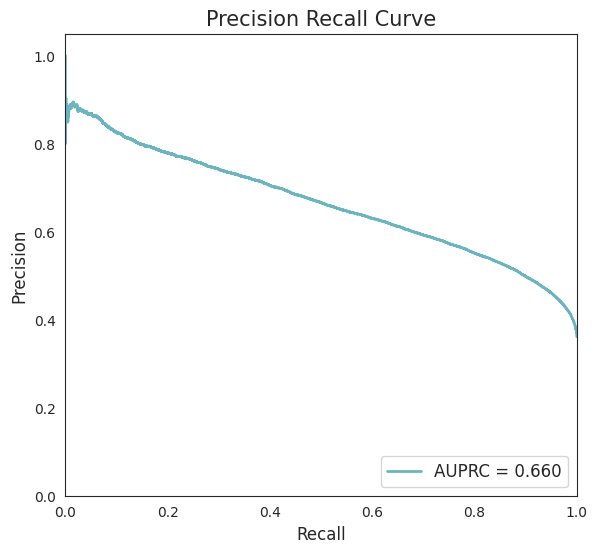

In [18]:
# テストデータに対するAUCPRを計算
precision, recall, thresholds = precision_recall_curve(test_df['y'], test_df['predict'])
aucpr = round(np.float32(auc(recall, precision)), 2)
print(f'Test AUPRC: {aucpr}')

# 結果をプロット
plt.figure(figsize=(6.6, 6))
sns.set_style("white")
plt.plot(recall, precision, color='#6BB5C0', lw=2, label=f'AUPRC = {aucpr:.3f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision Recall Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.savefig(os.path.join(output_dir, 'figures/' + prc_figure_name_without_lag))
plt.show()

In [19]:
# ==========================================================
#  キャリブレーション（Isotonic Regressionで確率補正）
# ==========================================================

# testデータをキャリブレーション用と評価用に分割
idx = np.arange(len(test_df))
idx_calib, idx_eval = train_test_split(
    idx, test_size=0.5, stratify=test_df['y'], random_state=710
)

y_true_calib = test_df.loc[idx_calib, 'y'].astype(int).values
y_prob_calib = test_df.loc[idx_calib, 'predict'].values

y_true_eval = test_df.loc[idx_eval, 'y'].astype(int).values
y_prob_eval = test_df.loc[idx_eval, 'predict'].values

# Isotonic Regressionで確率補正を学習
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(y_prob_calib, y_true_calib)

# 評価用データの確率を補正してDataFrameに反映
test_df.loc[idx_eval, 'predict'] = iso.transform(y_prob_eval)

## Calibration plot

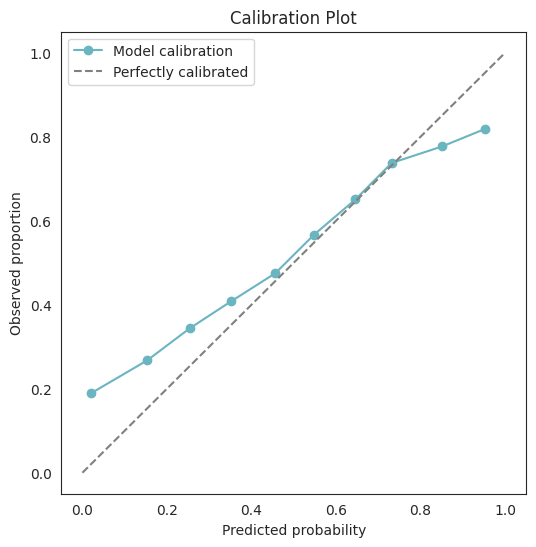

In [20]:
# Compute calibration curve
prob_true, prob_pred = calibration_curve(test_df['y'], test_df['predict'], n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label="Model calibration", color='#6BB5C0')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")

plt.xlabel("Predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Plot")
plt.legend()
# plt.grid(True)
plt.savefig(os.path.join(output_dir, 'figures/' + calibration_figure_name_without_lag))
plt.show()

## SHAPの確認

In [21]:
new_h2o_frame = test_full.drop('y')
test_full["unstable"] = test_full["unstable"].asnumeric()

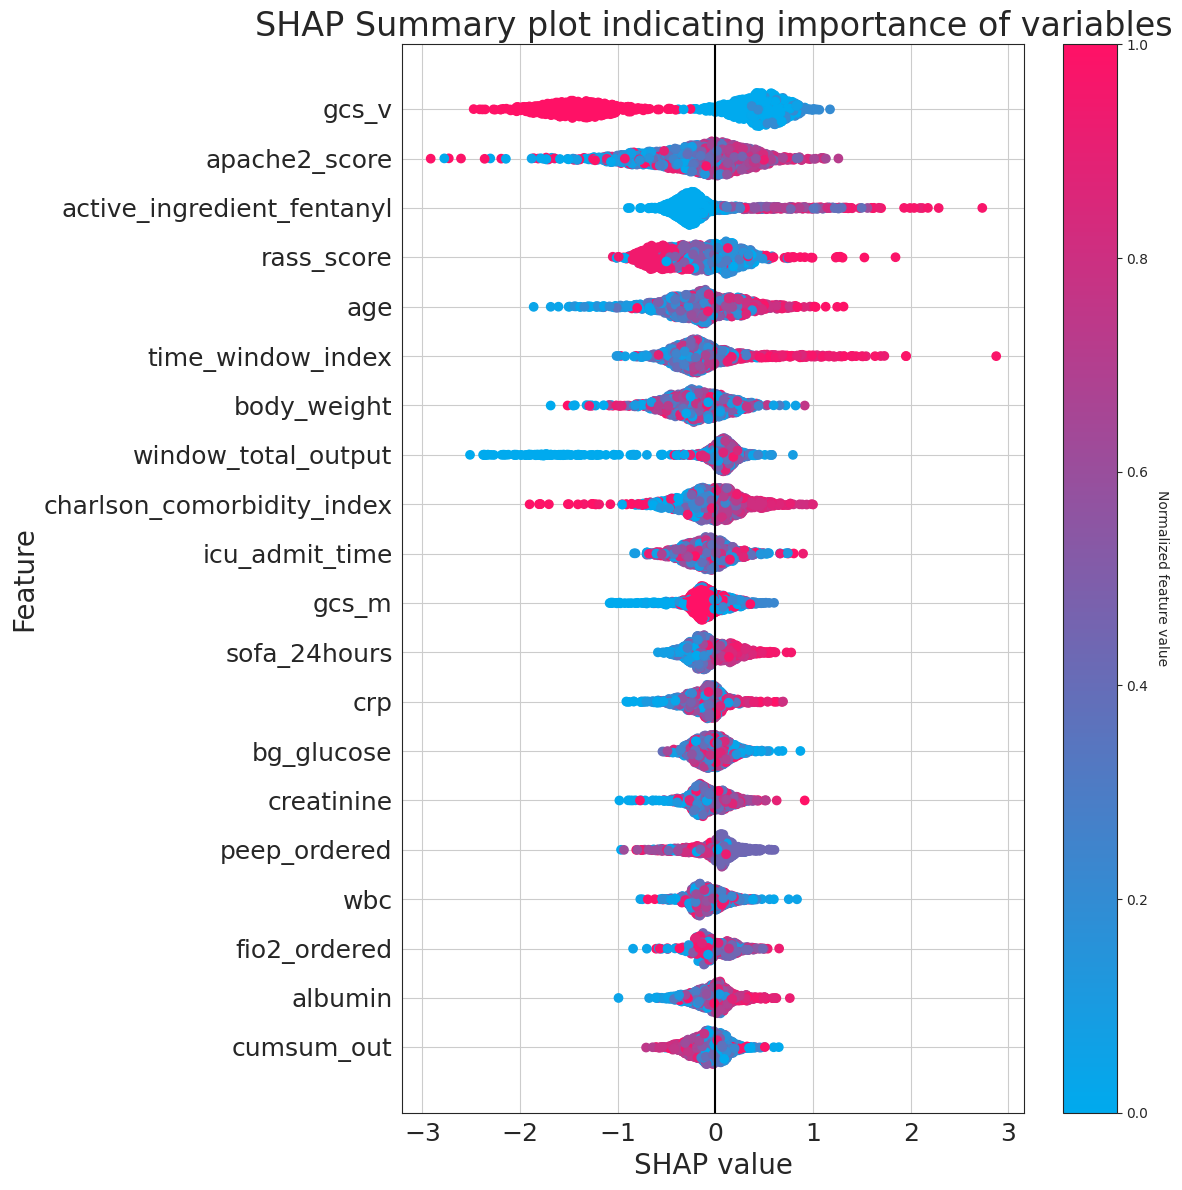

In [22]:
# SHAPのプロットを作成
shap_plot = best_model.shap_summary_plot(new_h2o_frame)

plt.title("SHAP Summary plot indicating importance of variables", fontsize=24)
plt.xlabel(plt.gca().get_xlabel(), fontsize=20)
plt.ylabel(plt.gca().get_ylabel(), fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures/' + SHAP_figure_file_name_without_lag))
plt.show()